# FBI NIBRS Crime Classification Pipeline
### ALY 6110: Big Data Analysis | Northeastern University

**Author:** Neeti Shah  
**Data Source:** [FBI Crime Data Explorer: NIBRS](https://cde.fbi.gov/dataexplorer)  

## Project Overview

This notebook builds a multi-model classification pipeline to predict the `crime_against` category (**Person / Property / Society**) for FBI NIBRS offense records across four U.S. states (CA, MA, NJ, ID) and four years (2021–2024).

## 1. Imports

In [20]:
# ── Standard library ─────────────────────────────────────────────────────
from __future__ import annotations

import re
import warnings
import zipfile
from io import BytesIO
from pathlib import Path
from typing import Dict, List, Tuple

# ── Numerical & data ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, LabelBinarizer, label_binarize
)
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc as sklearn_auc,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import joblib
try:
    import requests
    REQUESTS_OK = True
except ImportError:
    REQUESTS_OK = False
    warnings.warn("requests not installed — auto-download section will show instructions only.")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12})
print('✅ Libraries loaded successfully.')


✅ Libraries loaded successfully.


## 2. Auto-Download FBI Data

The FBI Crime Data Explorer provides bulk NIBRS CSVs for each state and year.  
Run the cell below to download all required folders automatically.  

> **Note:** Each state-year zip is ~30–200 MB. Total download ~2–3 GB for all 16 folders.  
> The cell is fault-tolerant: it skips folders that already exist.


In [21]:
# ── Auto-Download Configuration ───────────────────────────────────────────
#
# Set SKIP_DOWNLOAD = True if data already exists on your machine.
# DOWNLOAD_DIR is where extracted folders will be placed.
# After running this cell, set BASE_DIR in Section 3 to DOWNLOAD_DIR.

SKIP_DOWNLOAD = False   # ← set True to skip downloading

DOWNLOAD_DIR = Path.home() / "nibrs_data"   # e.g. C:/Users/you/nibrs_data
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

# States and years to download
STATES = ["CA", "MA", "NJ", "ID"]
YEARS  = [2021, 2022, 2023, 2024]

# FBI CDE bulk download URL pattern
# Format: https://cde.fbi.gov/api/nibrs/download?states=CA&year=2021&file=nibrs
CDE_URL = "https://cde.fbi.gov/api/nibrs/download?states={state}&year={year}&file=nibrs"

def download_nibrs(state: str, year: int, dest_dir: Path) -> None:
    """Downloads and extracts one NIBRS state-year zip from the FBI CDE."""
    folder_name = f"{state}-{year}"
    target_folder = dest_dir / folder_name

    if target_folder.exists():
        print(f"  ⏭  {folder_name} already exists — skipping.")
        return

    url = CDE_URL.format(state=state, year=year)
    print(f"  ⬇  Downloading {folder_name} from {url} ...")

    if not REQUESTS_OK:
        print(f"     requests not available. Please download manually from:")
        print(f"     https://cde.fbi.gov/dataexplorer")
        return

    try:
        response = requests.get(url, timeout=300, stream=True)
        response.raise_for_status()

        content = BytesIO()
        downloaded = 0
        for chunk in response.iter_content(chunk_size=8192):
            content.write(chunk)
            downloaded += len(chunk)
        print(f"     Downloaded {downloaded / 1e6:.1f} MB")

        content.seek(0)
        with zipfile.ZipFile(content) as zf:
            # Extract into a sub-folder named STATE-YEAR
            target_folder.mkdir(parents=True, exist_ok=True)
            for member in zf.namelist():
                filename = Path(member).name
                if filename:  # skip directory entries
                    data = zf.read(member)
                    (target_folder / filename).write_bytes(data)
        print(f"     ✅ Extracted to {target_folder}")

    except Exception as e:
        print(f"     ❌ Failed for {folder_name}: {e}")
        print(f"     Manual download: https://cde.fbi.gov/dataexplorer")


if not SKIP_DOWNLOAD:
    print(f"Downloading NIBRS data to: {DOWNLOAD_DIR}")
    print(f"States: {STATES}  Years: {YEARS}\n")
    for state in STATES:
        for year in YEARS:
            download_nibrs(state, year, DOWNLOAD_DIR)
    print("\n✅ Download complete. Set BASE_DIR = DOWNLOAD_DIR in Section 3.")
else:
    print("SKIP_DOWNLOAD = True — skipping download.")
    print(f"Make sure your data is in a folder with STATE-YEAR subfolders (e.g. CA-2021).")


States: ['CA', 'MA', 'NJ', 'ID']  Years: [2021, 2022, 2023, 2024]

  ⬇  Downloading CA-2021 from https://cde.fbi.gov/api/nibrs/download?states=CA&year=2021&file=nibrs ...
     ❌ Failed for CA-2021: HTTPSConnectionPool(host='cde.fbi.gov', port=443): Max retries exceeded with url: /api/nibrs/download?states=CA&year=2021&file=nibrs (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000025AAD10FC80>: Failed to resolve 'cde.fbi.gov' ([Errno 11001] getaddrinfo failed)"))
     Manual download: https://cde.fbi.gov/dataexplorer
  ⬇  Downloading CA-2022 from https://cde.fbi.gov/api/nibrs/download?states=CA&year=2022&file=nibrs ...
     ❌ Failed for CA-2022: HTTPSConnectionPool(host='cde.fbi.gov', port=443): Max retries exceeded with url: /api/nibrs/download?states=CA&year=2022&file=nibrs (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000025AAD10C3B0>: Failed to resolve 'cde.fbi.gov' ([Errno 11001] getaddrinfo failed)"))
     Manual 

## 3. Configuration

In [22]:
# ── Path Configuration ────────────────────────────────────────────────────
#
# BASE_DIR must point to the parent folder that contains state-year
# sub-folders (e.g. CA-2021, MA-2023, NJ-2024).
#
# If you ran the auto-download above, uncomment the DOWNLOAD_DIR line:
#   BASE_DIR = DOWNLOAD_DIR
#
# Otherwise, update the path below to match your local setup.

BASE_DIR = Path(
    r"C:\Users\neeti\OneDrive\Desktop\NEU\ALY 6110\ALY_6110\ALY_6110"
)
# BASE_DIR = DOWNLOAD_DIR   # ← uncomment if you used auto-download

# ── Model Configuration ────────────────────────────────────────────────────

# Classification target: Person / Property / Society
TARGET_COL   = 'crime_against'

# Max rows for model training (full dataset ~5.4M rows)
MAX_ROWS     = 250_000

# Held-out test fraction
TEST_SIZE    = 0.20

# Reproducibility seed
RANDOM_STATE = 42

# Directory for serialised models
OUTPUT_DIR = Path('model_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"BASE_DIR  : {BASE_DIR}")
print(f"TARGET_COL: {TARGET_COL}")
print(f"MAX_ROWS  : {MAX_ROWS:,}")


BASE_DIR  : C:\Users\neeti\OneDrive\Desktop\NEU\ALY 6110\ALY_6110\ALY_6110
TARGET_COL: crime_against
MAX_ROWS  : 250,000


## 4. File Mappings

In [23]:
# FACT_FILES maps logical table names to NIBRS CSV filenames present in
# every state-year sub-folder.
FACT_FILES = {
    'incident': 'NIBRS_INCIDENT.csv',
    'offense':  'NIBRS_OFFENSE.csv',
}

# LOOKUP_FILES maps logical names to reference / dimension tables that are
# read once from the first state-year folder that contains them.
LOOKUP_FILES = {
    'offense_type':  'NIBRS_OFFENSE_TYPE.csv',
    'location_type': 'NIBRS_LOCATION_TYPE.csv',
    'month':         'NIBRS_MONTH.csv',
}

# All CSV columns are read as strings to prevent silent numeric coercion
# of ID columns that happen to look like integers.
READ_KWARGS = dict(dtype=str, low_memory=False)

print("File mappings configured.")
print(f"  Fact tables  : {list(FACT_FILES.keys())}")
print(f"  Lookup tables: {list(LOOKUP_FILES.keys())}")


File mappings configured.
  Fact tables  : ['incident', 'offense']
  Lookup tables: ['offense_type', 'location_type', 'month']


## 5. Helper Functions

In [24]:
# ── Directory discovery ────────────────────────────────────────────────────

def find_state_year_dirs(base_dir: Path) -> List[Tuple[Path, str, int]]:
    """Scans base_dir for sub-folders matching the STATE-YEAR pattern
    (e.g. CA-2021) and returns a sorted list of (path, state, year) tuples."""
    pat = re.compile(r'^[A-Z]{2}-\d{4}$')
    dirs: List[Tuple[Path, str, int]] = []
    for p in base_dir.iterdir():
        if p.is_dir() and pat.match(p.name):
            st, yr = p.name.split('-')
            dirs.append((p, st, int(yr)))
    dirs.sort(key=lambda x: (x[1], x[2]))
    return dirs


# ── Fact and lookup loaders ────────────────────────────────────────────────

def load_fact_table(state_year_dirs: List[Tuple[Path, str, int]],
                    file_name: str) -> pd.DataFrame:
    """Reads a fact-table CSV from every state-year folder, tags each slice
    with state and year columns, and concatenates into one DataFrame."""
    frames = []
    for folder, st, yr in state_year_dirs:
        fp = folder / file_name
        if not fp.exists():
            continue
        df = pd.read_csv(fp, **READ_KWARGS)
        df.columns = [c.lower() for c in df.columns]
        df['state'] = st
        df['year']  = yr
        frames.append(df)
    if not frames:
        raise FileNotFoundError(
            f'No files found for {file_name}. '
            'Verify BASE_DIR and folder structure.'
        )
    return pd.concat(frames, ignore_index=True)


def load_lookup_table(state_year_dirs: List[Tuple[Path, str, int]],
                      file_name: str) -> pd.DataFrame:
    """Loads a reference table from the first state-year folder that
    contains it; reference tables are identical across all folders."""
    for folder, _, _ in state_year_dirs:
        fp = folder / file_name
        if fp.exists():
            df = pd.read_csv(fp, **READ_KWARGS)
            df.columns = [c.lower() for c in df.columns]
            return df
    raise FileNotFoundError(f'Lookup file not found: {file_name}')


# ── Multi-table join ───────────────────────────────────────────────────────

def build_offense_view(df_incident:      pd.DataFrame,
                        df_offense:       pd.DataFrame,
                        lk_offense_type:  pd.DataFrame,
                        lk_location_type: pd.DataFrame,
                        lk_month:         pd.DataFrame) -> pd.DataFrame:
    """Builds the core analytical frame by joining offense records to their
    offense-type label, location description, incident timestamp, and month
    reference. validate='m:1' guards every join against row multiplication
    from unexpected duplicate keys in lookup tables.

    offense_category_name is retained in the view for EDA only. It is
    excluded from the model feature set to prevent data leakage into
    crime_against (the two columns are derived from the same lookup row).
    """
    # Step 1: attach offense name, category, and crime_against label
    view = df_offense.merge(
        lk_offense_type[['offense_code', 'offense_name',
                          'offense_category_name', 'crime_against']],
        on='offense_code', how='left', validate='m:1'
    )

    # Step 2: attach human-readable location name
    view = view.merge(
        lk_location_type[['location_id', 'location_name']],
        on='location_id', how='left', validate='m:1'
    )

    # Step 3: attach incident date, hour, and month ID
    view = view.merge(
        df_incident[['incident_id', 'incident_date',
                     'incident_hour', 'nibrs_month_id', 'state', 'year']],
        on=['incident_id', 'state', 'year'], how='left', validate='m:1'
    )

    # Step 4: attach month number; nibrs_month_id is deduplicated first
    # so that the m:1 cardinality constraint is preserved.
    month_lk = (
        lk_month[['nibrs_month_id', 'month_num', 'data_year']]
        .drop_duplicates(subset=['nibrs_month_id'])
    )
    view = view.merge(month_lk, on='nibrs_month_id', how='left', validate='m:1')

    return view


# ── Type coercion ──────────────────────────────────────────────────────────

def coerce_numeric(s: pd.Series) -> pd.Series:
    """Converts a Series to float, setting unparseable values to NaN."""
    return pd.to_numeric(s, errors='coerce')


# ── Feature preparation (leakage-safe) ────────────────────────────────────

def prepare_modeling_df(offense_view: pd.DataFrame, target: str) -> pd.DataFrame:
    """Selects and cleans the columns used for modelling.

    offense_category_name is intentionally excluded from the feature set.
    Including it would constitute data leakage: it is derived from the same
    lookup row as crime_against and would directly encode the target,
    producing artificially perfect accuracy that would not generalise to
    real inference.
    """
    df = offense_view.copy()
    df['incident_hour'] = coerce_numeric(df.get('incident_hour'))
    df['month_num']     = coerce_numeric(df.get('month_num'))
    df['year']          = coerce_numeric(df.get('year'))

    feature_cols = ['state', 'year', 'month_num', 'incident_hour', 'location_name']
    keep_cols    = feature_cols + [target]

    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f'Missing columns required for modelling: {missing}')

    model_df = df[keep_cols].dropna(subset=[target]).copy()
    model_df = model_df[model_df[target].astype(str).str.strip() != '']
    return model_df


# ── Preprocessor factory ───────────────────────────────────────────────────

def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    """Constructs a ColumnTransformer that applies separate pipelines to
    categorical and numeric feature subsets.

    Categorical : most-frequent imputation → one-hot encoding
    Numeric     : median imputation → StandardScaler (with_mean=False
                  preserves sparse matrix structure)
    """
    cat_cols = [c for c in X.columns if X[c].dtype == 'object']
    num_cols = [c for c in X.columns if c not in cat_cols]

    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
    ])
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler(with_mean=False)),
    ])

    return ColumnTransformer(
        transformers=[
            ('cat', cat_pipe, cat_cols),
            ('num', num_pipe, num_cols),
        ],
        remainder='drop',
        sparse_threshold=0.3,
    )

print("Helper functions defined.")


Helper functions defined.


## 6. Data Loading & Join

In [25]:
# BASE_DIR is validated before scanning so that a clear, actionable
# error message surfaces if the path has not been updated.
if not isinstance(BASE_DIR, Path):
    BASE_DIR = Path(BASE_DIR)

if not BASE_DIR.exists():
    raise FileNotFoundError(
        f"BASE_DIR does not exist: {BASE_DIR}\n"
        "Update BASE_DIR in Section 3 to the folder containing "
        "state-year sub-folders (e.g. CA-2021, MA-2023).\n"
        "Or run Section 2 to auto-download the data."
    )

# Discover state-year folders dynamically so new folders are picked up
# automatically without any code changes.
state_year_dirs = find_state_year_dirs(BASE_DIR)
print(f"State-year folders found: {len(state_year_dirs)}")
for p, st, yr in state_year_dirs:
    print(f"  {p.name}")

if not state_year_dirs:
    raise ValueError(
        f"No STATE-YEAR folders found inside {BASE_DIR}.\n"
        "Expected folder names like: CA-2022, MA-2023"
    )

# Fact tables span all state-year folders.
print("\nLoading fact tables...")
df_incident = load_fact_table(state_year_dirs, FACT_FILES['incident'])
print(f"  NIBRS_INCIDENT : {df_incident.shape[0]:,} rows × {df_incident.shape[1]} cols")

df_offense = load_fact_table(state_year_dirs, FACT_FILES['offense'])
print(f"  NIBRS_OFFENSE  : {df_offense.shape[0]:,} rows × {df_offense.shape[1]} cols")

# Lookup / dimension tables are read once from the first available folder.
print("\nLoading lookup tables...")
lk_offense_type  = load_lookup_table(state_year_dirs, LOOKUP_FILES['offense_type'])
lk_location_type = load_lookup_table(state_year_dirs, LOOKUP_FILES['location_type'])
lk_month         = load_lookup_table(state_year_dirs, LOOKUP_FILES['month'])
print(f"  NIBRS_OFFENSE_TYPE  : {lk_offense_type.shape}")
print(f"  NIBRS_LOCATION_TYPE : {lk_location_type.shape}")
print(f"  NIBRS_MONTH         : {lk_month.shape}")

# Build the analytical frame.
print("\nBuilding offense_view (multi-table join)...")
offense_view = build_offense_view(
    df_incident, df_offense,
    lk_offense_type, lk_location_type, lk_month
)
print(f"  offense_view : {offense_view.shape[0]:,} rows × {offense_view.shape[1]} cols")
offense_view.head(3)


State-year folders found: 16
  CA-2021
  CA-2022
  CA-2023
  CA-2024
  ID-2021
  ID-2022
  ID-2023
  ID-2024
  MA-2021
  MA-2022
  MA-2023
  MA-2024
  NJ-2021
  NJ-2022
  NJ-2023
  NJ-2024

Loading fact tables...
  NIBRS_INCIDENT : 4,799,260 rows × 17 cols
  NIBRS_OFFENSE  : 5,472,395 rows × 10 cols

Loading lookup tables...
  NIBRS_OFFENSE_TYPE  : (86, 8)
  NIBRS_LOCATION_TYPE : (47, 3)
  NIBRS_MONTH         : (118176, 13)

Building offense_view (multi-table join)...
  offense_view : 5,472,395 rows × 19 cols


,data_year_x,offense_id,incident_id,offense_code,attempt_complete_flag,location_id,num_premises_entered,method_entry_code,state,year,offense_name,offense_category_name,crime_against,location_name,incident_date,incident_hour,nibrs_month_id,month_num,data_year_y
0,2021,170403568,141774651,11A,C,35,NaN,NaN,CA,2021,Rape,Sex Offenses,Person,Residence/Home,2021-08-26,12,40314544,8,2021
1,2021,164352006,136500530,13A,C,25,NaN,NaN,CA,2021,Aggravated Assault,Assault Offenses,Person,Highway/Road/Alley/Street/Sidewalk,2021-01-01,0,3105156,1,2021
2,2021,164444800,136580646,13B,C,35,NaN,NaN,CA,2021,Simple Assault,Assault Offenses,Person,Residence/Home,2021-01-01,0,3105156,1,2021


## 7. Exploratory Data Analysis

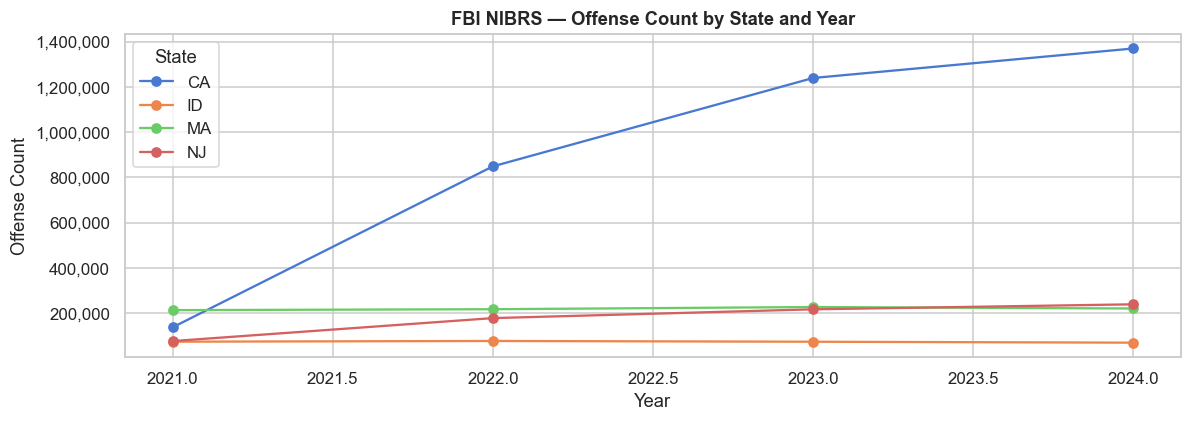

state  data_year_num  offense_count
   CA           2021         136848
   CA           2022         848369
   CA           2023        1239106
   CA           2024        1369571
   ID           2021          73420
   ID           2022          76626
   ID           2023          73294
   ID           2024          69156
   MA           2021         212959
   MA           2022         217004
   MA           2023         226712
   MA           2024         220214
   NJ           2021          76176
   NJ           2022         177702
   NJ           2023         216553
   NJ           2024         238685


In [26]:
# ── Helper numeric columns ────────────────────────────────────────────────
offense_view['incident_hour_num'] = coerce_numeric(offense_view.get('incident_hour'))
offense_view['month_num_num']     = coerce_numeric(offense_view.get('month_num'))
offense_view['data_year_num']     = coerce_numeric(
    offense_view.get('data_year', offense_view.get('year'))
)

# ── 7a. Offense count by state and year ───────────────────────────────────
state_year_counts = (
    offense_view.dropna(subset=['data_year_num'])
    .groupby(['state', 'data_year_num'])
    .size()
    .reset_index(name='offense_count')
    .sort_values(['state', 'data_year_num'])
)

fig, ax = plt.subplots(figsize=(11, 4))
for state, grp in state_year_counts.groupby('state'):
    ax.plot(grp['data_year_num'], grp['offense_count'], marker='o', label=state)
ax.set_title('FBI NIBRS — Offense Count by State and Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Offense Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='State')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_state_year_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(state_year_counts.to_string(index=False))


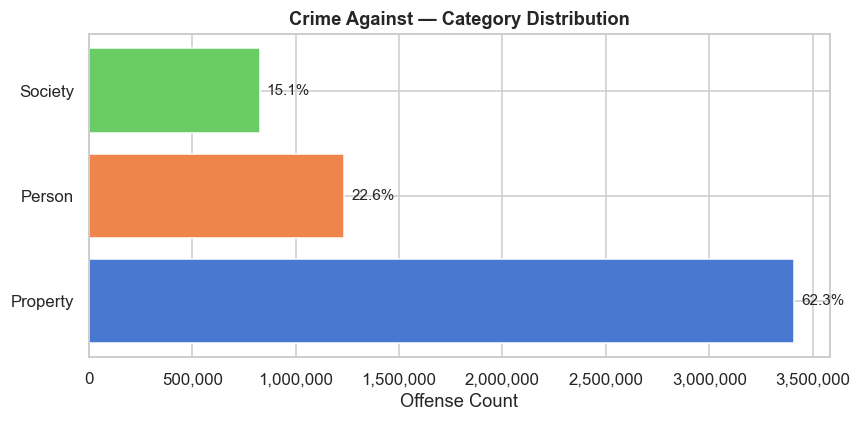

crime_against   count  pct
     Property 3411607 62.3
       Person 1234503 22.6
      Society  826285 15.1


In [27]:
# ── 7b. Crime Against category distribution ───────────────────────────────
ca_dist = (
    offense_view.dropna(subset=['crime_against'])
    .groupby('crime_against')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='count')
)
ca_dist['pct'] = (ca_dist['count'] / ca_dist['count'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(ca_dist['crime_against'], ca_dist['count'],
               color=sns.color_palette('muted')[:len(ca_dist)])
for bar, pct in zip(bars, ca_dist['pct']):
    ax.text(bar.get_width() + ca_dist['count'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{pct}%', va='center', fontsize=10)
ax.set_title('Crime Against — Category Distribution', fontweight='bold')
ax.set_xlabel('Offense Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_crime_against_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(ca_dist.to_string(index=False))


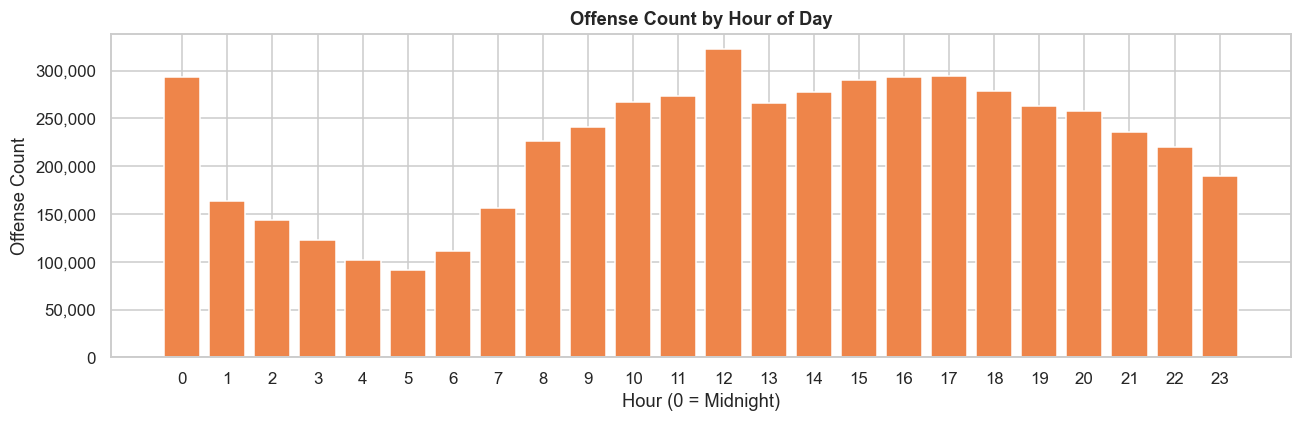

In [28]:
# ── 7c. Incident hour distribution ────────────────────────────────────────
hour_counts = (
    offense_view['incident_hour_num']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hour_counts.index, hour_counts.values,
       color=sns.color_palette('muted')[1], edgecolor='white')
ax.set_title('Offense Count by Hour of Day', fontweight='bold')
ax.set_xlabel('Hour (0 = Midnight)')
ax.set_ylabel('Offense Count')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_hour_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


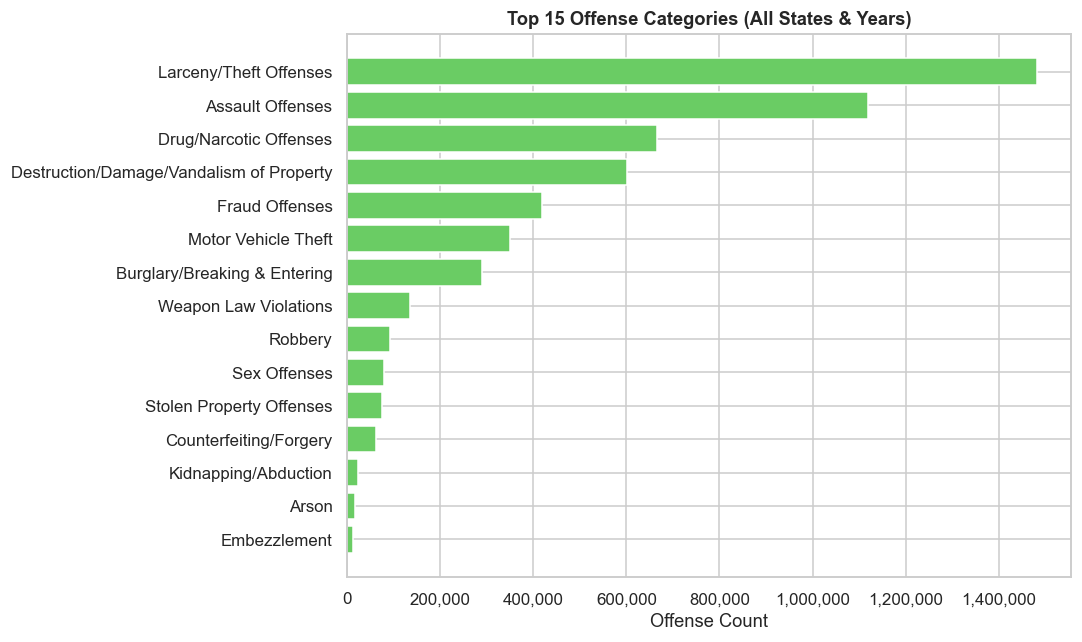

In [29]:
# ── 7d. Top 15 offense categories ─────────────────────────────────────────
top_cats = (
    offense_view.dropna(subset=['offense_category_name'])
    .groupby('offense_category_name')
    .size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name='count')
    .sort_values('count')
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_cats['offense_category_name'], top_cats['count'],
        color=sns.color_palette('muted')[2])
ax.set_title('Top 15 Offense Categories (All States & Years)', fontweight='bold')
ax.set_xlabel('Offense Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_top_offense_categories.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Modeling Dataset

In [30]:
# prepare_modeling_df selects the leakage-safe feature set.
# offense_category_name is excluded — see function docstring for full rationale.
model_df = prepare_modeling_df(offense_view, TARGET_COL)
print(f"Rows available for modelling: {len(model_df):,}")

# Sample to MAX_ROWS for tractable training times.
if MAX_ROWS is not None and len(model_df) > MAX_ROWS:
    model_df = model_df.sample(n=MAX_ROWS, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"Sampled to: {len(model_df):,} rows")

y = model_df[TARGET_COL].astype(str)
X = model_df.drop(columns=[TARGET_COL])

# Stratified split preserves Person / Property / Society class ratio
# in both training and test partitions.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"\nClass distribution in sampled data:")
print(y.value_counts().to_string())
print(f"\nTrain : {X_train.shape[0]:,} rows")
print(f"Test  : {X_test.shape[0]:,} rows")
print(f"Features: {X_train.columns.tolist()}")


Rows available for modelling: 5,472,395
Sampled to: 250,000 rows

Class distribution in sampled data:
crime_against
Property    155959
Person       56410
Society      37631

Train : 200,000 rows
Test  : 50,000 rows
Features: ['state', 'year', 'month_num', 'incident_hour', 'location_name']


## 9. Evaluation Helpers

In [31]:
def evaluate_and_plot(name: str,
                      pipe,
                      X_test: pd.DataFrame,
                      y_test: pd.Series,
                      normalize: str = 'true') -> dict:
    """Generates predictions from a fitted Pipeline and computes:
      - Accuracy, Macro F1, ROC-AUC (one-vs-rest macro)
      - Full per-class classification report
      - Normalised confusion matrix
      - Multi-class ROC curves (one curve per class)

    ROC-AUC for RidgeClassifier:
      RidgeClassifier exposes decision_function but NOT predict_proba.
      The raw decision scores are converted to pseudo-probabilities via
      scipy softmax before being passed to roc_auc_score, which requires
      proper probability estimates for the multi_class='ovr' strategy.
    """
    from scipy.special import softmax as sp_softmax

    preds = pipe.predict(X_test)
    classes = np.array(sorted(y_test.unique()))

    # ── Probability scores ─────────────────────────────────────────────────
    if hasattr(pipe, 'predict_proba'):
        proba = pipe.predict_proba(X_test)
    elif hasattr(pipe, 'decision_function'):
        # Convert raw decision scores to calibrated probabilities via softmax
        raw = pipe.decision_function(X_test)
        proba = sp_softmax(raw, axis=1)
    else:
        proba = None

    # ── Scalar metrics ─────────────────────────────────────────────────────
    acc = accuracy_score(y_test, preds)
    f1m = f1_score(y_test, preds, average='macro')
    if proba is not None:
        auc_val = roc_auc_score(y_test, proba,
                                multi_class='ovr', average='macro')
    else:
        auc_val = float('nan')

    # ── Console output ─────────────────────────────────────────────────────
    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Macro F1 : {f1m:.4f}')
    print(f'  ROC-AUC  : {auc_val:.4f}  (OVR macro)')
    print(f'\nClassification Report:')
    print(classification_report(y_test, preds, digits=4))

    # ── Confusion matrix ───────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, normalize=normalize, cmap='Blues', ax=axes[0]
    )
    axes[0].set_title(f'{name}\nConfusion Matrix (normalised)', fontweight='bold')

    # ── Multi-class ROC curves ─────────────────────────────────────────────
    if proba is not None:
        y_bin = label_binarize(y_test, classes=classes)
        for i, cls in enumerate(classes):
            fpr_c, tpr_c, _ = roc_curve(y_bin[:, i], proba[:, i])
            auc_c = sklearn_auc(fpr_c, tpr_c)
            axes[1].plot(fpr_c, tpr_c, lw=2,
                         label=f'{cls} (AUC={auc_c:.3f})')
        axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'{name}\nROC Curves (one-vs-rest)', fontweight='bold')
        axes[1].legend(fontsize=9)
    else:
        axes[1].axis('off')
        axes[1].text(0.5, 0.5, 'ROC N/A', ha='center', va='center')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'eval_{name.replace(" ", "_").lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'model':    name,
        'accuracy': acc,
        'macro_f1': f1m,
        'roc_auc':  auc_val,
    }


def plot_feature_importance(pipe, top_n: int = 20,
                             title: str = 'Feature Importance') -> None:
    """Plots the top-N mean-decrease-in-impurity importances from
    any tree-based model inside a fitted Pipeline."""
    prep  = pipe.named_steps['prep']
    model = pipe.named_steps['model']

    if not hasattr(model, 'feature_importances_'):
        print(f'{title}: model does not expose feature_importances_ — skipping.')
        return

    importances = model.feature_importances_

    try:
        feature_names = prep.get_feature_names_out()
    except Exception:
        feature_names = None

    if feature_names is not None:
        fi = (pd.DataFrame({'feature': feature_names, 'importance': importances})
                .nlargest(top_n, 'importance')
                .sort_values('importance'))
        fig, ax = plt.subplots(figsize=(9, 7))
        ax.barh(fi['feature'], fi['importance'],
                color=sns.color_palette('muted')[0])
    else:
        idx = np.argsort(importances)[-top_n:]
        fig, ax = plt.subplots(figsize=(9, 7))
        ax.barh([str(i) for i in idx], importances[idx],
                color=sns.color_palette('muted')[0])

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Mean Decrease in Impurity')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'fi_{title.replace(" ", "_").lower()[:40]}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

print("Evaluation helpers defined.")


Evaluation helpers defined.


## 10. Preprocessor

In [32]:
# The preprocessor is fitted on the training set only so that its learned
# parameters (OHE vocabulary, imputation fill values, scaling statistics)
# are derived exclusively from training data — no test leakage.
preprocessor = build_preprocessor(X_train)
preprocessor.fit(X_train)

results = []

print("Preprocessor fitted.")
print(f"  Categorical features : {[c for c in X_train.columns if X_train[c].dtype == 'object']}")
print(f"  Numeric features     : {[c for c in X_train.columns if X_train[c].dtype != 'object']}")


Preprocessor fitted.
  Categorical features : ['state', 'location_name']
  Numeric features     : ['year', 'month_num', 'incident_hour']


## 11. Logistic Regression


  Logistic Regression
  Accuracy : 0.6402
  Macro F1 : 0.3527
  ROC-AUC  : 0.7173  (OVR macro)

Classification Report:
              precision    recall  f1-score   support

      Person     0.5433    0.0589    0.1063     11282
    Property     0.6420    0.9804    0.7759     31192
     Society     0.6696    0.1012    0.1759      7526

    accuracy                         0.6402     50000
   macro avg     0.6183    0.3802    0.3527     50000
weighted avg     0.6239    0.6402    0.5345     50000



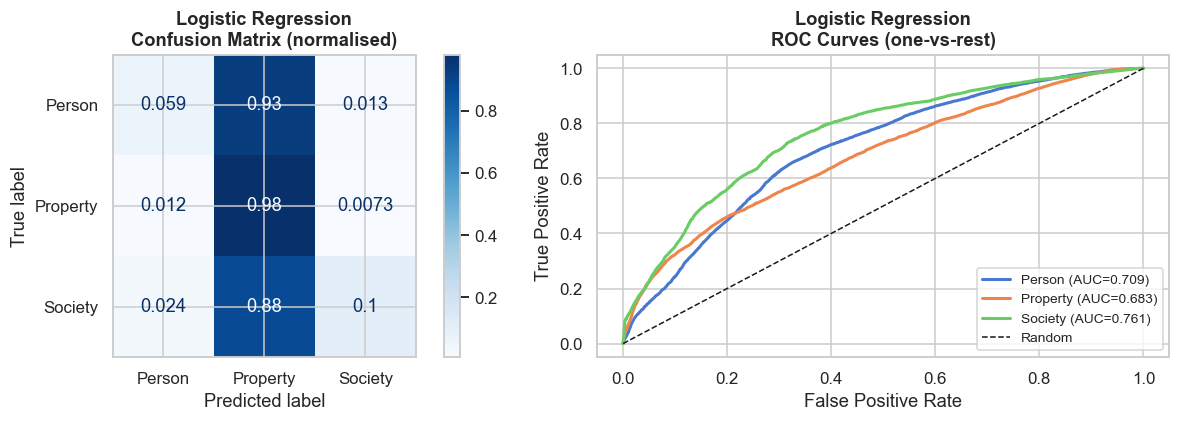

In [33]:
# Logistic Regression — interpretable linear baseline.
# max_iter=2000 ensures convergence on the sparse one-hot matrix.
# The lbfgs solver handles multinomial classification natively.
lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)

lr_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', lr),
])

lr_pipe.fit(X_train, y_train)
results.append(evaluate_and_plot('Logistic Regression', lr_pipe, X_test, y_test))


## 12. Ridge Classifier


  Ridge Classifier
  Accuracy : 0.6418
  Macro F1 : 0.3594
  ROC-AUC  : 0.7178  (OVR macro)

Classification Report:
              precision    recall  f1-score   support

      Person     0.5191    0.0795    0.1379     11282
    Property     0.6445    0.9779    0.7769     31192
     Society     0.7331    0.0919    0.1634      7526

    accuracy                         0.6418     50000
   macro avg     0.6322    0.3831    0.3594     50000
weighted avg     0.6295    0.6418    0.5404     50000



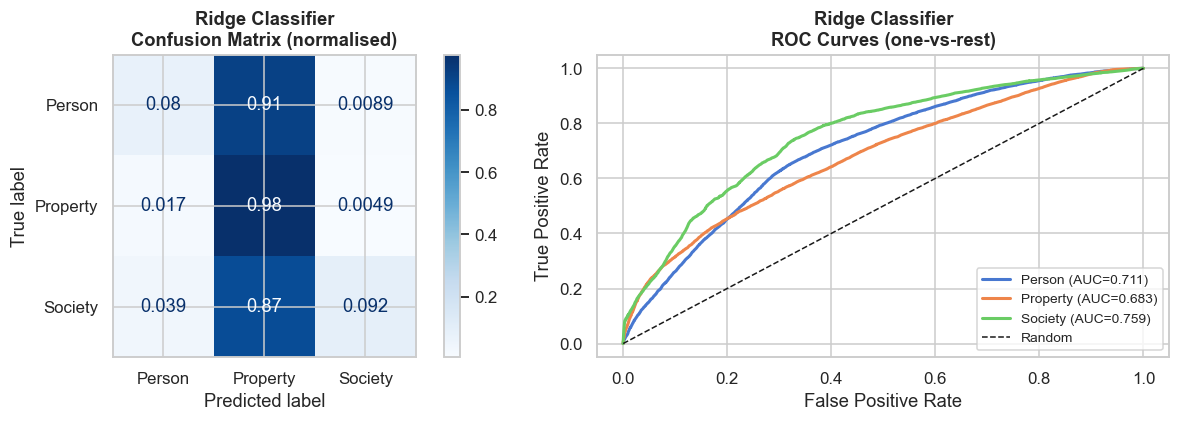

In [34]:
# RidgeClassifier applies L2-regularised regression to classification by
# treating class labels as continuous targets. It is significantly faster
# than Logistic Regression on large sparse matrices.
#
# ROC-AUC fix: RidgeClassifier does not expose predict_proba. To produce
# valid probability estimates for ROC-AUC scoring, the classifier is wrapped
# in CalibratedClassifierCV (Platt scaling / isotonic regression), which
# calibrates the decision_function outputs into true class probabilities.
# This is the scikit-learn-recommended approach for classifiers without
# native probability support.

ridge_base = RidgeClassifier()

# cv=5 uses 5-fold cross-validation to fit the calibration model.
# method='sigmoid' applies Platt scaling — appropriate for small to medium datasets.
ridge_calibrated = CalibratedClassifierCV(ridge_base, cv=5, method='sigmoid')

ridge_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', ridge_calibrated),
])

ridge_pipe.fit(X_train, y_train)
results.append(evaluate_and_plot('Ridge Classifier', ridge_pipe, X_test, y_test))


## 13. Decision Tree


  Decision Tree
  Accuracy : 0.6415
  Macro F1 : 0.4152
  ROC-AUC  : 0.7215  (OVR macro)

Classification Report:
              precision    recall  f1-score   support

      Person     0.4868    0.1736    0.2559     11282
    Property     0.6582    0.9331    0.7719     31192
     Society     0.5738    0.1343    0.2177      7526

    accuracy                         0.6415     50000
   macro avg     0.5729    0.4136    0.4152     50000
weighted avg     0.6068    0.6415    0.5721     50000



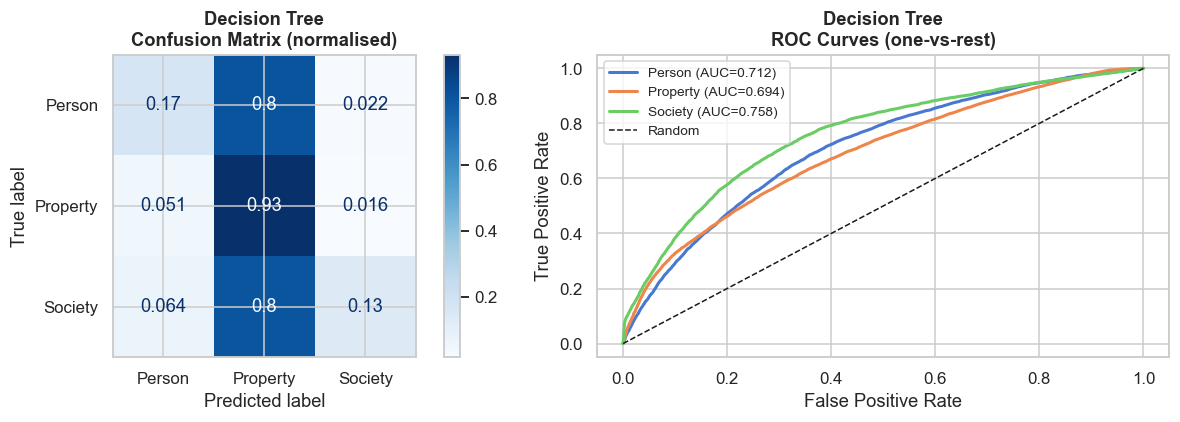

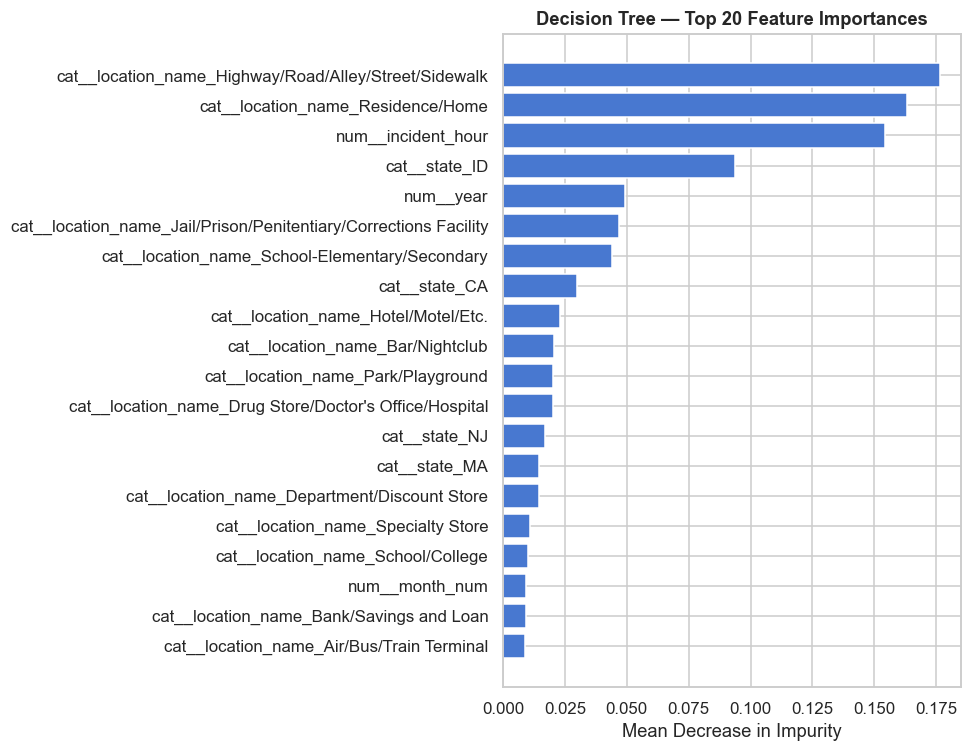

In [35]:
# Decision Tree — interpretable non-linear baseline.
# min_samples_leaf=10 prevents individual leaves from fitting noise
# by requiring at least 10 training samples per leaf node.
dt = DecisionTreeClassifier(random_state=RANDOM_STATE, min_samples_leaf=10)

dt_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', dt),
])

dt_pipe.fit(X_train, y_train)
results.append(evaluate_and_plot('Decision Tree', dt_pipe, X_test, y_test))

plot_feature_importance(dt_pipe, top_n=20,
                         title='Decision Tree — Top 20 Feature Importances')


## 14. Random Forest


  Random Forest
  Accuracy : 0.6434
  Macro F1 : 0.4099
  ROC-AUC  : 0.7265  (OVR macro)

Classification Report:
              precision    recall  f1-score   support

      Person     0.5004    0.1552    0.2369     11282
    Property     0.6565    0.9428    0.7740     31192
     Society     0.5927    0.1342    0.2189      7526

    accuracy                         0.6434     50000
   macro avg     0.5832    0.4107    0.4099     50000
weighted avg     0.6117    0.6434    0.5693     50000



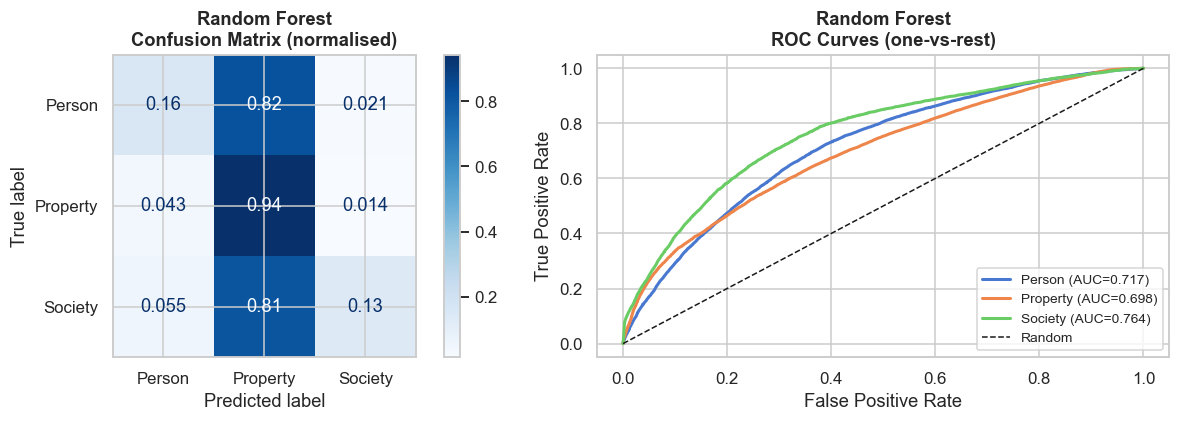

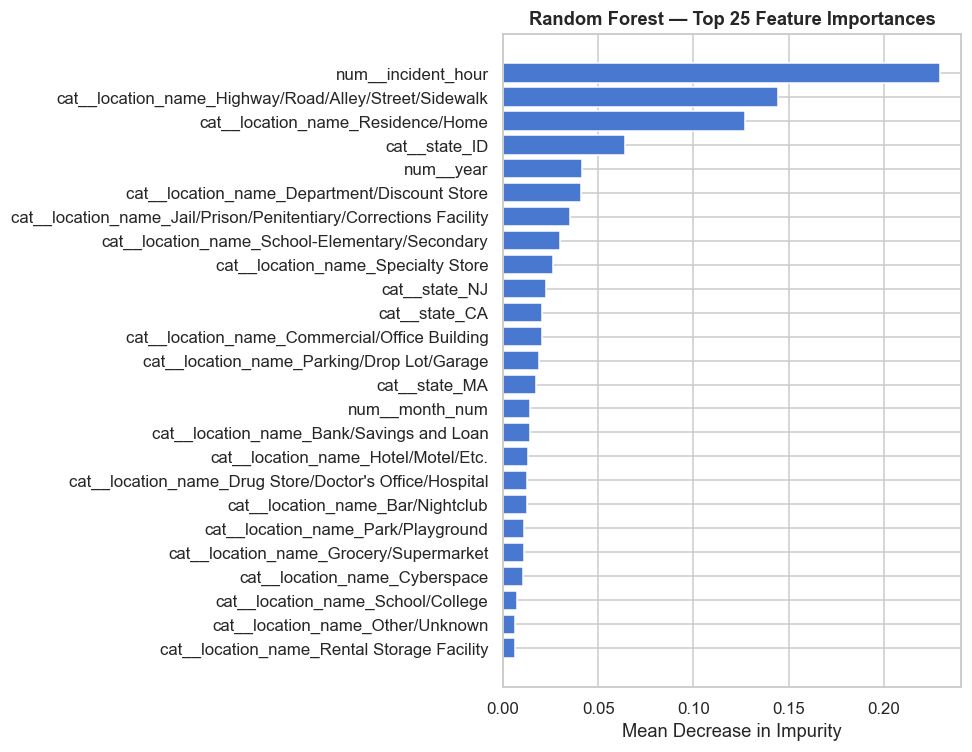

In [36]:
# Random Forest — ensemble of 300 decision trees.
# Each tree is trained on a bootstrap sample with a random feature subset,
# which reduces variance relative to a single deep tree.
# n_jobs=-1 enables parallel training across all available CPU cores.
# min_samples_leaf=5 provides light regularisation at the leaf level.
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    min_samples_leaf=5,
)

rf_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', rf),
])

rf_pipe.fit(X_train, y_train)
results.append(evaluate_and_plot('Random Forest', rf_pipe, X_test, y_test))

plot_feature_importance(rf_pipe, top_n=25,
                         title='Random Forest — Top 25 Feature Importances')


## 15. Model Comparison

Model Comparison (sorted by ROC-AUC):
              model  accuracy  macro_f1  roc_auc
      Random Forest   0.64338  0.409928 0.726467
      Decision Tree   0.64146  0.415163 0.721537
   Ridge Classifier   0.64182  0.359406 0.717771
Logistic Regression   0.64018  0.352716 0.717260


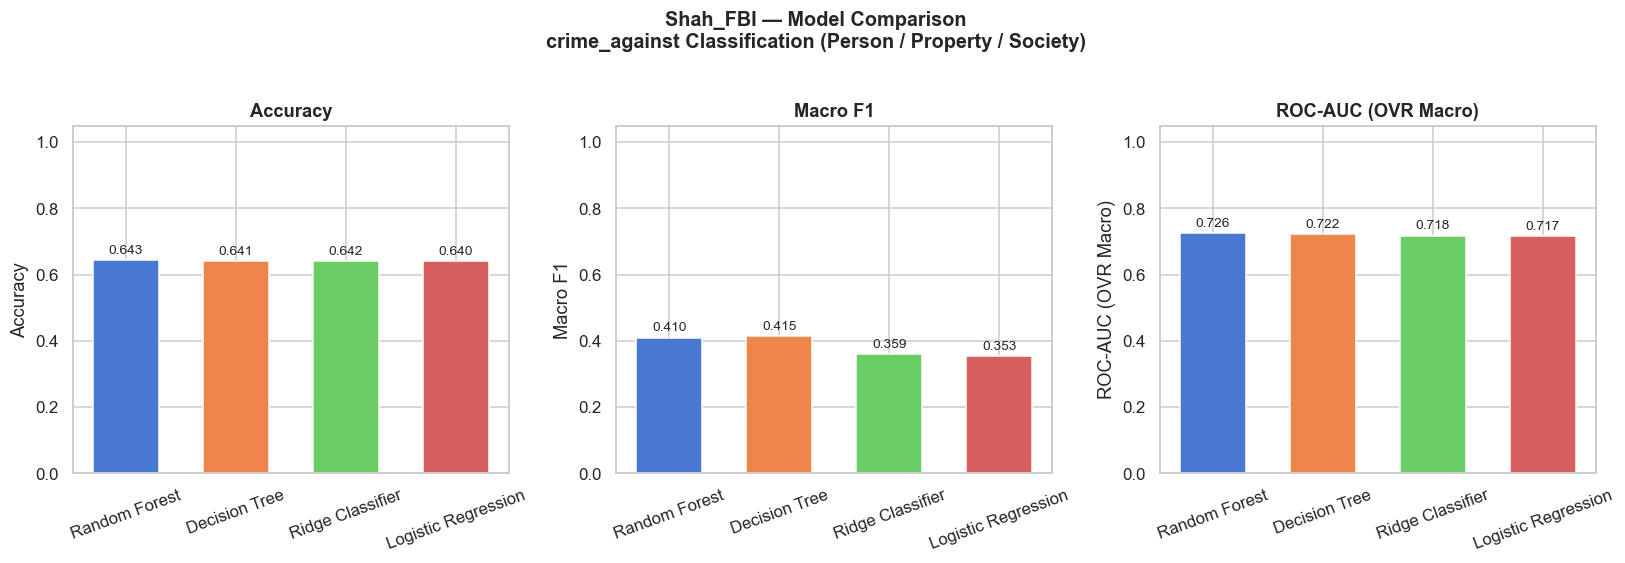

In [37]:
# ── Comparison table ──────────────────────────────────────────────────────
metrics_df = (
    pd.DataFrame(results)
    .sort_values('roc_auc', ascending=False)
    .reset_index(drop=True)
)

print('Model Comparison (sorted by ROC-AUC):')
print(metrics_df.to_string(index=False))

# ── Bar charts ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette = sns.color_palette('muted', len(metrics_df))

for ax, col, label in zip(
    axes,
    ['accuracy', 'macro_f1', 'roc_auc'],
    ['Accuracy', 'Macro F1', 'ROC-AUC (OVR Macro)']
):
    bars = ax.bar(metrics_df['model'], metrics_df[col],
                  color=palette, edgecolor='white', width=0.6)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, metrics_df[col]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle(
    'Shah_FBI — Model Comparison\ncrime_against Classification (Person / Property / Society)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [38]:
# ── Save best model ────────────────────────────────────────────────────────
best_row    = metrics_df.iloc[0]
best_name   = best_row['model']
best_models = {'Logistic Regression': lr_pipe,
               'Ridge Classifier':    ridge_pipe,
               'Decision Tree':       dt_pipe,
               'Random Forest':       rf_pipe}

best_pipe   = best_models[best_name]
save_path   = OUTPUT_DIR / f'best_model_{best_name.replace(" ", "_").lower()}.pkl'
joblib.dump(best_pipe, save_path)
print(f"✅ Best model ({best_name}, ROC-AUC={best_row['roc_auc']:.4f}) saved to {save_path}")

# ── Final summary ──────────────────────────────────────────────────────────
print("\n── Final Model Summary ──────────────────────────────────────────────────")
print(metrics_df[['model','accuracy','macro_f1','roc_auc']].to_string(index=False))
print("\n── Output files ──────────────────────────────────────────────────────────")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name}")


✅ Best model (Random Forest, ROC-AUC=0.7265) saved to model_outputs\best_model_random_forest.pkl

── Final Model Summary ──────────────────────────────────────────────────
              model  accuracy  macro_f1  roc_auc
      Random Forest   0.64338  0.409928 0.726467
      Decision Tree   0.64146  0.415163 0.721537
   Ridge Classifier   0.64182  0.359406 0.717771
Logistic Regression   0.64018  0.352716 0.717260

── Output files ──────────────────────────────────────────────────────────
  best_model_random_forest.pkl
  eda_crime_against_dist.png
  eda_hour_distribution.png
  eda_state_year_trend.png
  eda_top_offense_categories.png
  eval_decision_tree.png
  eval_logistic_regression.png
  eval_random_forest.png
  eval_ridge_classifier.png
  fi_decision_tree_—_top_20_feature_importanc.png
  fi_random_forest_—_top_25_feature_importanc.png
  model_comparison.png
